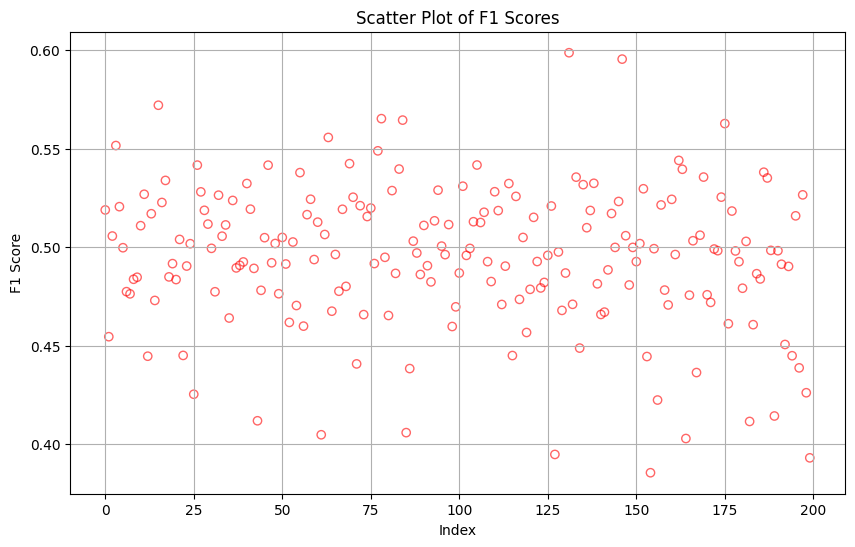

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = './EncodedChromosomes_v5_results.csv'
# Load the data
df = pd.read_csv(CSV_PATH)

# Extract F1 scores
f1_scores = df['F1']

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(range(len(f1_scores)), f1_scores, alpha=0.6, edgecolor='r', facecolor='none')
plt.title('Scatter Plot of F1 Scores')
plt.xlabel('Index')
plt.ylabel('F1 Score')
plt.grid(True)
plt.show()


Varianza explicada acumulada con 12 componentes (no escalado): 99.92%
XGBoost with PCA (without scaling) - MAE: 0.0301, MSE: 0.0015, R2: -0.3882


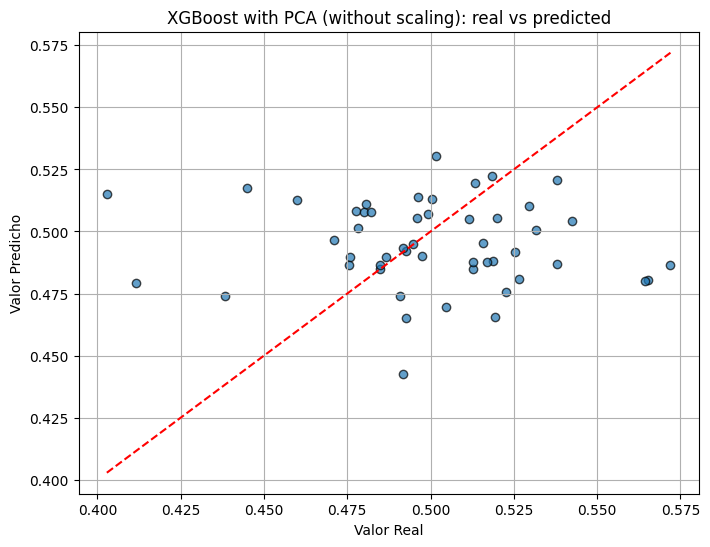

Varianza explicada acumulada con 12 componentes (con escalado): 48.46%
XGBoost with PCA (with scaling) - MAE: 0.0295, MSE: 0.0015, R2: -0.3533


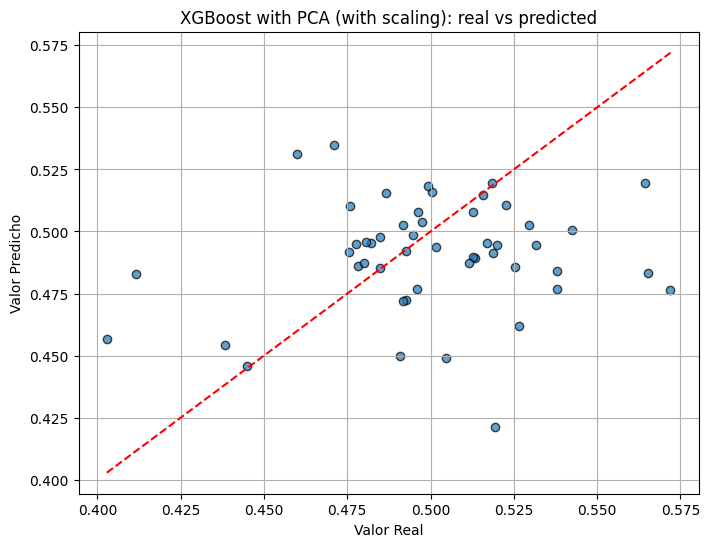

Modelo XGBoost y PCA guardados en la carpeta './surrogates_v5.2'.
Mejores hiperparámetros encontrados: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
XGBoost with PCA (GridSearch) - MAE: 0.0251, MSE: 0.0011, R2: -0.0118


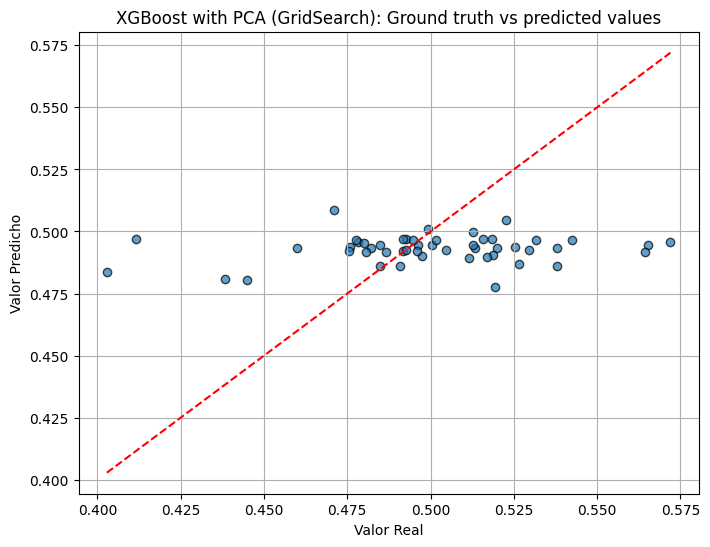

Mejor modelo XGBoost (GridSearch) guardado.
SVR with PCA - MAE: 0.0254, MSE: 0.0012, R2: -0.0411


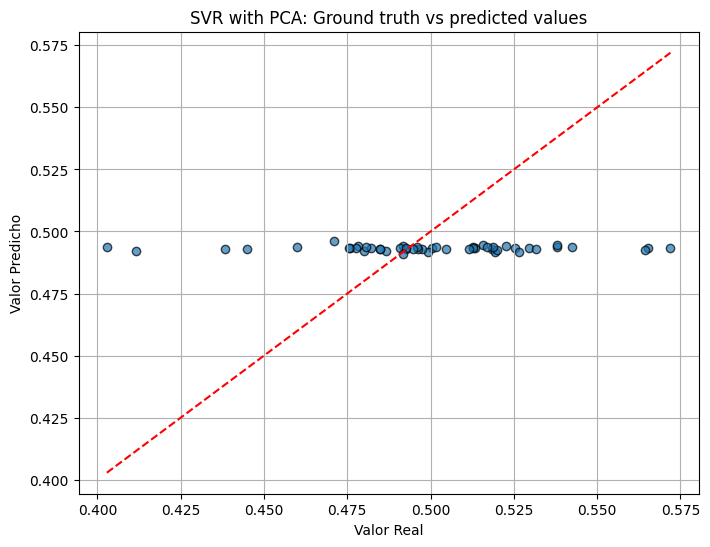

Modelo SVR guardado.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     F1   No. Observations:                  150
Model:                            GLM   Df Residuals:                      137
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.887
Date:                Tue, 22 Apr 2025   Deviance:                      0.74822
Time:                        17:22:16   Pearson chi2:                    0.746
No. Iterations:                     3   Pseudo R-squ. (CS):          0.0004573
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0248      0.16

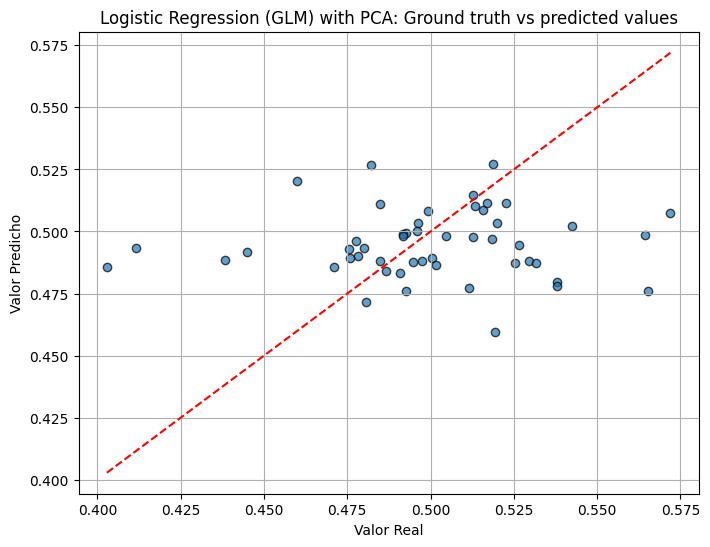

Modelo GLM guardado en: ./surrogates_v5.2\glm_model.pkl
Modelo XGBoost y PCA guardados en la carpeta './surrogates_v5.2'.
Mejores hiperparámetros encontrados: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}
XGBoost (GridSearch) with PCA - MAE: 0.0251, MSE: 0.0011, R2: -0.0118


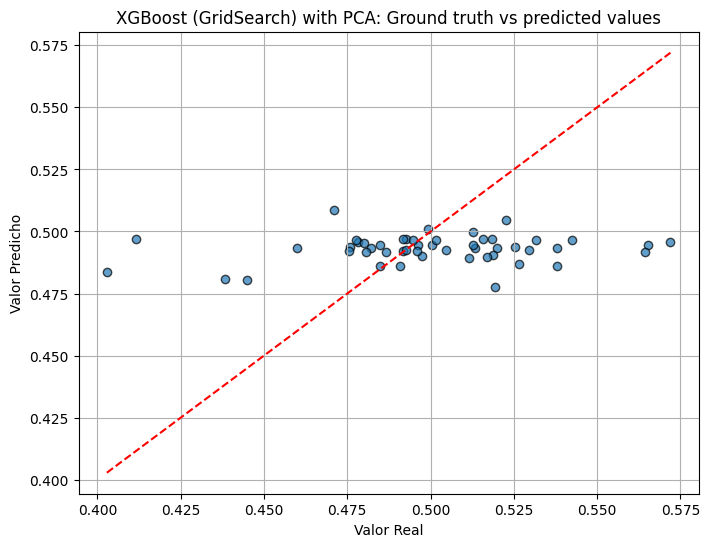

Mejor modelo XGBoost (GridSearch) guardado.
SVR with PCA - MAE: 0.0254, MSE: 0.0012, R2: -0.0411


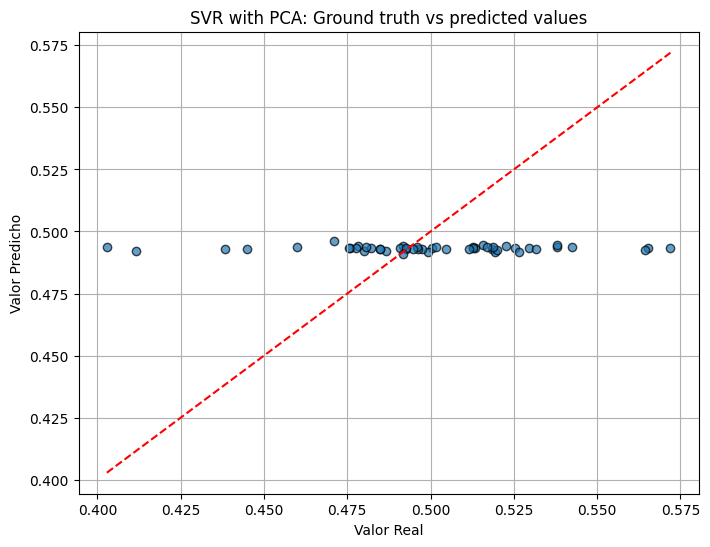

Modelo SVR guardado.
                 Generalized Linear Model Regression Results                  
Dep. Variable:                     F1   No. Observations:                  150
Model:                            GLM   Df Residuals:                      137
Model Family:                Binomial   Df Model:                           12
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67.887
Date:                Tue, 22 Apr 2025   Deviance:                      0.74822
Time:                        17:22:16   Pearson chi2:                    0.746
No. Iterations:                     3   Pseudo R-squ. (CS):          0.0004573
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0248      0.16

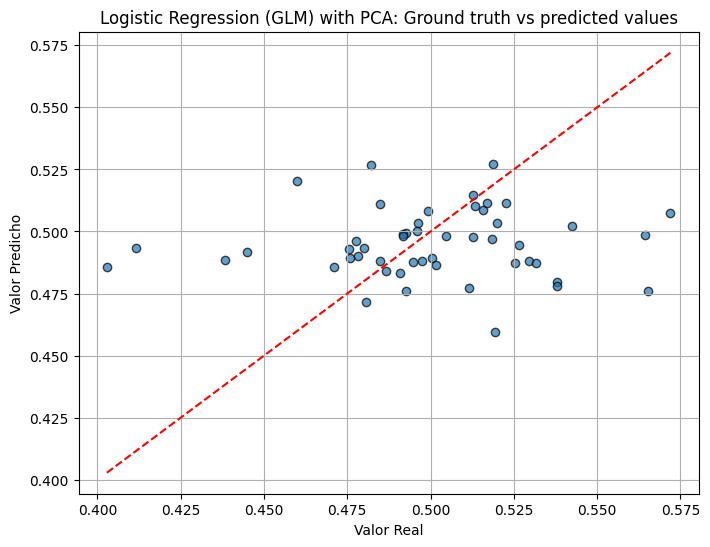

Modelo GLM guardado en: ./surrogates_v5.2\glm_model.pkl


In [10]:
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.decomposition import PCA
import joblib

SAVE_PATH = "./surrogates_v5.2"
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
    print(f"Directorio '{SAVE_PATH}' creado.")

# ------------------------------
# Cargar y Preprocesar el Dataset
# ------------------------------
# Se asume que 'df' ya está cargado en el notebook
# Convertir la columna 'Encoded Architecture' de string a lista de enteros
# Sólo aplicamos literal_eval si el elemento es un str, 
# en otro caso lo dejamos tal cual (lista)
df['Encoded Architecture'] = df['Encoded Architecture'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Expandir la lista en 'Encoded Architecture' a 48 columnas
num_features = len(df['Encoded Architecture'].iloc[0])
arch_cols = [f'arch_{i}' for i in range(num_features)]
encoded_arch_df = pd.DataFrame(df['Encoded Architecture'].tolist(), columns=arch_cols)

# Definir la variable objetivo para regresión (F1 score, valores entre 0 y 1)
y_reg = df['F1']

# ------------------------------
# Aplicar PCA para reducir a 12 componentes
# ------------------------------
pca = PCA(n_components=12, random_state=42)
X_pca = pca.fit_transform(encoded_arch_df)

# Imprimir la varianza explicada acumulada
print("Varianza explicada acumulada con 12 componentes (no escalado): {:.2%}".format(np.sum(pca.explained_variance_ratio_)))

# Dividir los datos para regresión
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# ------------------------------
# Función para graficar Predicted vs Ground Truth (Regresión)
# ------------------------------
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title(title)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.grid(True)
    plt.show()

# ------------------------------
# Modelo Base: XGBoost con PCA
# ------------------------------
model_xgb = xgb.XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

# Evaluar el modelo base XGBoost
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
r2 = r2_score(y_test, pred_xgb)
# Evaluar el modelo base XGBoost (sin escalado)
print("XGBoost with PCA (without scaling) - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae, mse, r2))
plot_scatter(
    y_test, 
    pred_xgb, 
    'XGBoost with PCA (without scaling): real vs predicted'
)

# Asumiendo que 'model_xgb' es el XGBRegressor entrenado sin scaler
# y 'pca' el PCA ajustado sobre X_scaled (o sobre encoded_arch_df en tu primer bloque)

# Guarda el PCA de la versión no escalada
joblib.dump(pca, os.path.join(SAVE_PATH, "pca_noscaler.pkl"))
# Guarda el modelo XGBoost de la versión no escalada
joblib.dump(model_xgb, os.path.join(SAVE_PATH, "xgboost_noscaler_model.pkl"))

# ------------------------------
# Guardar el modelo base y el PCA
# ------------------------------
import pandas as pd
import numpy as np
import ast
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from sklearn.decomposition import PCA
import joblib

# ------------------------------
# Cargar y Preprocesar el Dataset
# ------------------------------
# Se asume que 'df' ya está cargado en el notebook
# Convertir la columna 'Encoded Architecture' de string a lista de enteros
# Sólo aplicamos literal_eval si el elemento es un str, 
# en otro caso lo dejamos tal cual (lista)
df['Encoded Architecture'] = df['Encoded Architecture'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Expandir la lista en 'Encoded Architecture' a 48 columnas
num_features = len(df['Encoded Architecture'].iloc[0])
arch_cols = [f'arch_{i}' for i in range(num_features)]
encoded_arch_df = pd.DataFrame(df['Encoded Architecture'].tolist(), columns=arch_cols)

from sklearn.preprocessing import StandardScaler

# ------------------------------
# Escalado de las características (varianza = 1)
# ------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(encoded_arch_df)

# (Opcional) guarda el scaler para reproducibilidad
joblib.dump(scaler, os.path.join(SAVE_PATH, 'scaler.joblib'))

# Definir la variable objetivo para regresión (F1 score, valores entre 0 y 1)
y_reg = df['F1']

# ------------------------------
# Aplicar PCA para reducir a 12 componentes
# ------------------------------
pca = PCA(n_components=12, random_state=42)
# X_pca = pca.fit_transform(encoded_arch_df)
X_pca = pca.fit_transform(X_scaled)

# Imprimir la varianza explicada acumulada
print("Varianza explicada acumulada con 12 componentes (con escalado): {:.2%}".format(np.sum(pca.explained_variance_ratio_)))

# Dividir los datos para regresión
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# ------------------------------
# Función para graficar Predicted vs Ground Truth (Regresión)
# ------------------------------
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title(title)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.grid(True)
    plt.show()

# ------------------------------
# Modelo Base: XGBoost con PCA
# ------------------------------
model_xgb = xgb.XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)

# Evaluar el modelo base XGBoost
mae = mean_absolute_error(y_test, pred_xgb)
mse = mean_squared_error(y_test, pred_xgb)
r2 = r2_score(y_test, pred_xgb)
# Evaluar el modelo base XGBoost (con escalado)
print("XGBoost with PCA (with scaling) - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae, mse, r2))
plot_scatter(
    y_test, 
    pred_xgb, 
    'XGBoost with PCA (with scaling): real vs predicted'
)

# ------------------------------
# Guardar el modelo base y el PCA
# ------------------------------

joblib.dump(model_xgb, os.path.join(SAVE_PATH, 'xgboost_model_pca.pkl'))
joblib.dump(pca, os.path.join(SAVE_PATH, 'pca_transformer.pkl'))
print(f"Modelo XGBoost y PCA guardados en la carpeta '{SAVE_PATH}'.")

# ------------------------------
# Grid Search para ajustar hiperparámetros (XGBoost)
# ------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_absolute_error',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)

# Evaluar el mejor modelo obtenido con GridSearch
best_model = grid_search.best_estimator_
pred_best = best_model.predict(X_test)
mae_best = mean_absolute_error(y_test, pred_best)
mse_best = mean_squared_error(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)
print("XGBoost with PCA (GridSearch) - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_best, mse_best, r2_best))

# Gráfica Predicted vs Ground Truth para el mejor modelo
plot_scatter(y_test, pred_best, 'XGBoost with PCA (GridSearch): Ground truth vs predicted values')

# Guardar el mejor modelo de GridSearch
joblib.dump(best_model, os.path.join(SAVE_PATH, 'xgboost_best_model_pca.pkl'))
print("Mejor modelo XGBoost (GridSearch) guardado.")

# ------------------------------
# Implementar Support Vector Regression (SVR)
# ------------------------------
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf')
model_svr.fit(X_train, y_train)
pred_svr = model_svr.predict(X_test)

mae_svr = mean_absolute_error(y_test, pred_svr)
mse_svr = mean_squared_error(y_test, pred_svr)
r2_svr = r2_score(y_test, pred_svr)
print("SVR with PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_svr, mse_svr, r2_svr))

# Gráfica para SVR
plot_scatter(y_test, pred_svr, 'SVR with PCA: Ground truth vs predicted values')

# Guardar el modelo SVR
joblib.dump(model_svr, os.path.join(SAVE_PATH, 'svr_model.pkl'))
print("Modelo SVR guardado.")

# ------------------------------
# Implementar Regresión Logística (GLM) para regresión de proporciones
# ------------------------------
import statsmodels.api as sm

# Usamos el mismo X_pca y y_reg (sin discretización) para el GLM
X_train_glm, X_test_glm, y_train_glm, y_test_glm = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# Agregar constante (requisito para statsmodels)
X_train_glm_const = sm.add_constant(X_train_glm)
X_test_glm_const = sm.add_constant(X_test_glm)

# Ajustar GLM con familia Binomial y enlace logit
glm_binom = sm.GLM(y_train_glm, X_train_glm_const, family=sm.families.Binomial())
result_glm = glm_binom.fit()
print(result_glm.summary())

# Realizar predicciones (los valores estarán entre 0 y 1)
pred_glm = result_glm.predict(X_test_glm_const)

mae_glm = mean_absolute_error(y_test_glm, pred_glm)
mse_glm = mean_squared_error(y_test_glm, pred_glm)
r2_glm = r2_score(y_test_glm, pred_glm)
print("Logistic Regression (GLM) with PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_glm, mse_glm, r2_glm))
plot_scatter(y_test_glm, pred_glm, 'Logistic Regression (GLM) with PCA: Ground truth vs predicted values')

# Guardar el modelo GLM utilizando el método propio de statsmodels
glm_save_path = os.path.join(SAVE_PATH, 'glm_model.pkl')
result_glm.save(glm_save_path)
print("Modelo GLM guardado en:", glm_save_path)


joblib.dump(model_xgb, os.path.join(SAVE_PATH, 'xgboost_model_pca.pkl'))
joblib.dump(pca, os.path.join(SAVE_PATH, 'pca_transformer.pkl'))
print(f"Modelo XGBoost y PCA guardados en la carpeta '{SAVE_PATH}'.")

# ------------------------------
# Grid Search para ajustar hiperparámetros (XGBoost)
# ------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42),
                           param_grid=param_grid,
                           scoring='neg_mean_absolute_error',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)

# Evaluar el mejor modelo obtenido con GridSearch
best_model = grid_search.best_estimator_
pred_best = best_model.predict(X_test)
mae_best = mean_absolute_error(y_test, pred_best)
mse_best = mean_squared_error(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)
print("XGBoost (GridSearch) with PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_best, mse_best, r2_best))

# Gráfica Predicted vs Ground Truth para el mejor modelo
plot_scatter(y_test, pred_best, 'XGBoost (GridSearch) with PCA: Ground truth vs predicted values')

# Guardar el mejor modelo de GridSearch
joblib.dump(best_model, os.path.join(SAVE_PATH, 'xgboost_best_model_pca.pkl'))
print("Mejor modelo XGBoost (GridSearch) guardado.")

# ------------------------------
# Implementar Support Vector Regression (SVR)
# ------------------------------
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf')
model_svr.fit(X_train, y_train)
pred_svr = model_svr.predict(X_test)

mae_svr = mean_absolute_error(y_test, pred_svr)
mse_svr = mean_squared_error(y_test, pred_svr)
r2_svr = r2_score(y_test, pred_svr)
print("SVR with PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_svr, mse_svr, r2_svr))

# Gráfica para SVR
plot_scatter(y_test, pred_svr, 'SVR with PCA: Ground truth vs predicted values')

# Guardar el modelo SVR
joblib.dump(model_svr, os.path.join(SAVE_PATH, 'svr_model.pkl'))
print("Modelo SVR guardado.")

# ------------------------------
# Implementar Regresión Logística (GLM) para regresión de proporciones
# ------------------------------
import statsmodels.api as sm

# Usamos el mismo X_pca y y_reg (sin discretización) para el GLM
X_train_glm, X_test_glm, y_train_glm, y_test_glm = train_test_split(X_pca, y_reg, test_size=0.25, random_state=42)

# Agregar constante (requisito para statsmodels)
X_train_glm_const = sm.add_constant(X_train_glm)
X_test_glm_const = sm.add_constant(X_test_glm)

# Ajustar GLM con familia Binomial y enlace logit
glm_binom = sm.GLM(y_train_glm, X_train_glm_const, family=sm.families.Binomial())
result_glm = glm_binom.fit()
print(result_glm.summary())

# Realizar predicciones (los valores estarán entre 0 y 1)
pred_glm = result_glm.predict(X_test_glm_const)

mae_glm = mean_absolute_error(y_test_glm, pred_glm)
mse_glm = mean_squared_error(y_test_glm, pred_glm)
r2_glm = r2_score(y_test_glm, pred_glm)
print("Logistic Regression (GLM) with PCA - MAE: {:.4f}, MSE: {:.4f}, R2: {:.4f}".format(mae_glm, mse_glm, r2_glm))
plot_scatter(y_test_glm, pred_glm, 'Logistic Regression (GLM) with PCA: Ground truth vs predicted values')

# Guardar el modelo GLM utilizando el método propio de statsmodels
glm_save_path = os.path.join(SAVE_PATH, 'glm_model.pkl')
result_glm.save(glm_save_path)
print("Modelo GLM guardado en:", glm_save_path)


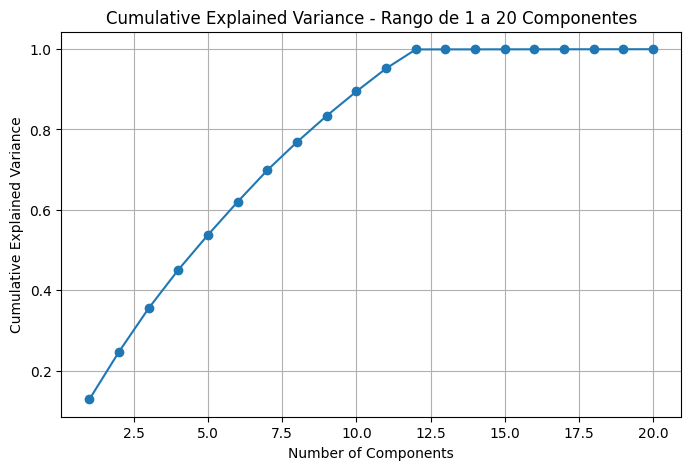

1 componentes: 12.88% of cumulative explained variance
2 componentes: 24.74% of cumulative explained variance
3 componentes: 35.56% of cumulative explained variance
4 componentes: 45.13% of cumulative explained variance
5 componentes: 53.81% of cumulative explained variance
6 componentes: 62.04% of cumulative explained variance
7 componentes: 69.90% of cumulative explained variance
8 componentes: 76.91% of cumulative explained variance
9 componentes: 83.42% of cumulative explained variance
10 componentes: 89.48% of cumulative explained variance
11 componentes: 95.18% of cumulative explained variance
12 componentes: 99.92% of cumulative explained variance
13 componentes: 99.93% of cumulative explained variance
14 componentes: 99.94% of cumulative explained variance
15 componentes: 99.95% of cumulative explained variance
16 componentes: 99.95% of cumulative explained variance
17 componentes: 99.96% of cumulative explained variance
18 componentes: 99.96% of cumulative explained variance
1

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = encoded_arch_df.values

max_components = 20
cumulative_variances = []

for n in range(1, max_components + 1):
    pca = PCA(n_components=n, random_state=42)
    pca.fit(X)
    cum_var = np.sum(pca.explained_variance_ratio_)
    cumulative_variances.append(cum_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, max_components + 1), cumulative_variances, marker='o')
plt.title('Cumulative Explained Variance - Rango de 1 a 20 Componentes')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Imprimir valores en pantalla
for i, cv in enumerate(cumulative_variances, start=1):
    print(f"{i} componentes: {cv:.2%} of cumulative explained variance")


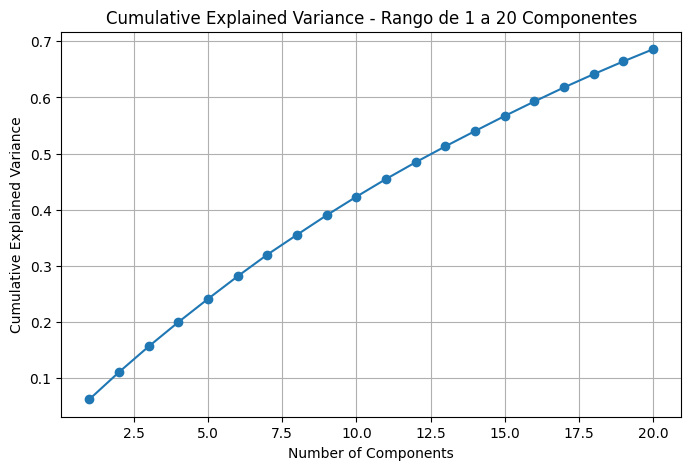

1 componentes: 6.23% of cumulative explained variance
2 componentes: 11.07% of cumulative explained variance
3 componentes: 15.65% of cumulative explained variance
4 componentes: 19.98% of cumulative explained variance
5 componentes: 24.12% of cumulative explained variance
6 componentes: 28.15% of cumulative explained variance
7 componentes: 32.01% of cumulative explained variance
8 componentes: 35.54% of cumulative explained variance
9 componentes: 39.02% of cumulative explained variance
10 componentes: 42.32% of cumulative explained variance
11 componentes: 45.47% of cumulative explained variance
12 componentes: 48.46% of cumulative explained variance
13 componentes: 51.29% of cumulative explained variance
14 componentes: 54.01% of cumulative explained variance
15 componentes: 56.70% of cumulative explained variance
16 componentes: 59.28% of cumulative explained variance
17 componentes: 61.78% of cumulative explained variance
18 componentes: 64.15% of cumulative explained variance
19

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = X_scaled

max_components = 20
cumulative_variances = []

for n in range(1, max_components + 1):
    pca = PCA(n_components=n, random_state=42)
    pca.fit(X)
    cum_var = np.sum(pca.explained_variance_ratio_)
    cumulative_variances.append(cum_var)

plt.figure(figsize=(8,5))
plt.plot(range(1, max_components + 1), cumulative_variances, marker='o')
plt.title('Cumulative Explained Variance - Rango de 1 a 20 Componentes')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Imprimir valores en pantalla
for i, cv in enumerate(cumulative_variances, start=1):
    print(f"{i} componentes: {cv:.2%} of cumulative explained variance")


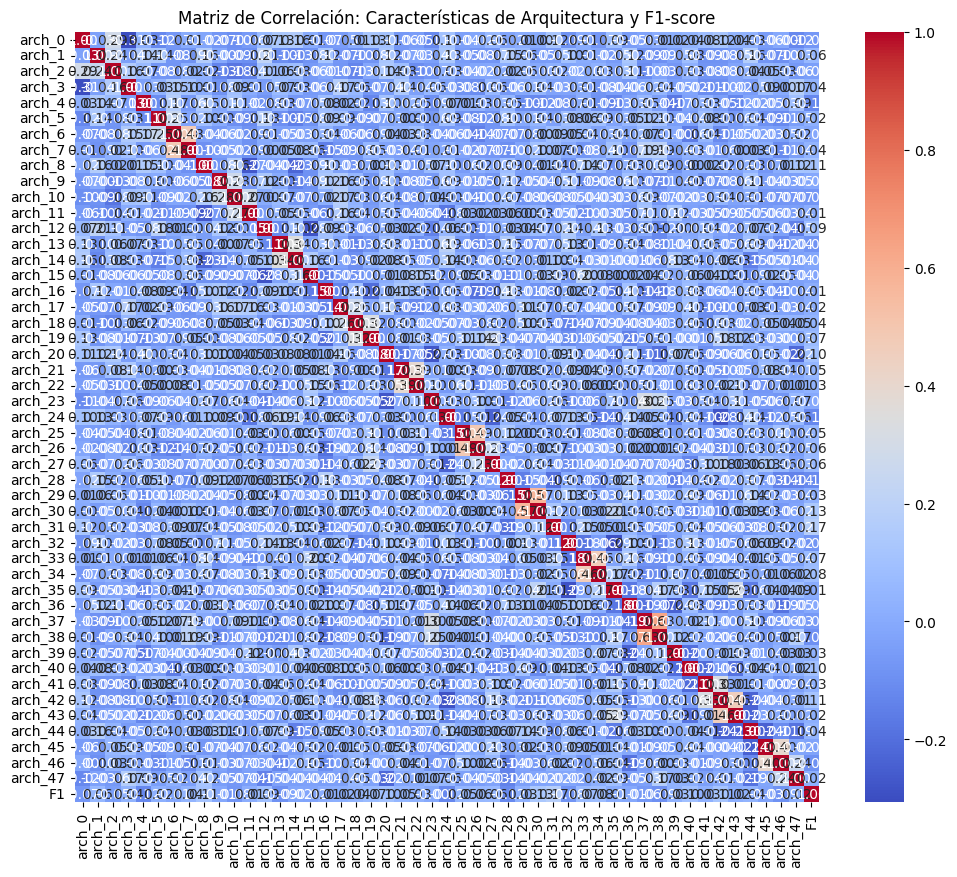

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Concatenar las 48 columnas de arquitectura con el F1-score para el análisis
df_corr = pd.concat([encoded_arch_df, df['F1']], axis=1)

# Calcular la matriz de correlación
corr_matrix = df_corr.corr()

# Graficar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matriz de Correlación: Características de Arquitectura y F1-score")
plt.show()


Epoch 1/1000


c:\Users\herna\anaconda3\envs\pytorch\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2587 - mae: 0.3956 - val_loss: 0.2311 - val_mae: 0.3610
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2296 - mae: 0.3734 - val_loss: 0.1562 - val_mae: 0.3214
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2104 - mae: 0.3504 - val_loss: 0.1171 - val_mae: 0.2881
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1523 - mae: 0.3018 - val_loss: 0.0903 - val_mae: 0.2548
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0913 - mae: 0.2300 - val_loss: 0.0760 - val_mae: 0.2288
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0869 - mae: 0.2375 - val_loss: 0.0654 - val_mae: 0.2131
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0895 - mae: 0.2262 - val_loss: 0.0555 - val_mae: 0.2016
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0682 - mae: 0.2058 - val_loss: 0.0513 - val_mae: 0.1958
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0762 - mae: 0.20

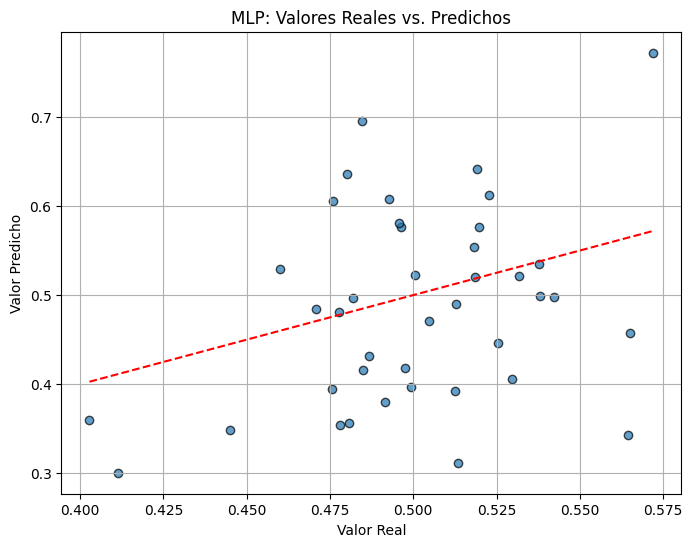

Epoch 1/1000


c:\Users\herna\anaconda3\envs\pytorch\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1087 - mae: 0.2829 - val_loss: 0.0134 - val_mae: 0.0975
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0158 - mae: 0.1054 - val_loss: 0.0121 - val_mae: 0.0855
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0116 - mae: 0.0837 - val_loss: 0.0100 - val_mae: 0.0876
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0074 - mae: 0.0716 - val_loss: 0.0070 - val_mae: 0.0665
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0046 - mae: 0.0523 - val_loss: 0.0064 - val_mae: 0.0625
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0033 - mae: 0.0458 - val_loss: 0.0066 - val_mae: 0.0648
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023 - mae: 0.0391 - val_loss: 0.0061 - val_mae: 0.0615
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0025 - mae: 0.0390 - val_loss: 0.0057 - val_mae: 0.0590
Epoch 9/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0020 - mae: 0.03

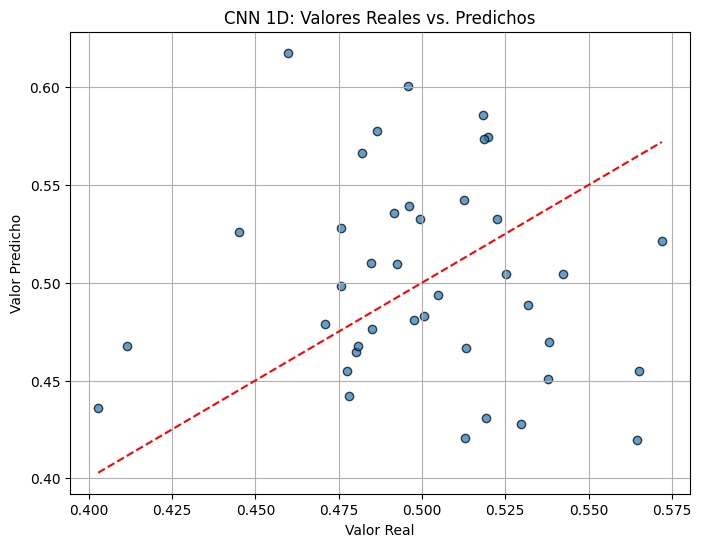

In [14]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------------------------------------------
# Cargar y Preprocesar el Dataset (Variable: data_df)
# ----------------------------------------------------------------
data_df = pd.read_csv(CSV_PATH)  # Asegúrate de tener el archivo en el directorio actual

# Convertir la columna 'Encoded Architecture' de string a lista de enteros
data_df['Encoded Architecture'] = data_df['Encoded Architecture'].apply(ast.literal_eval)

# Expandir la lista en 'Encoded Architecture' a múltiples columnas
num_features = len(data_df['Encoded Architecture'].iloc[0])
arch_cols = [f'arch_{i}' for i in range(num_features)]
arch_df = pd.DataFrame(data_df['Encoded Architecture'].tolist(), columns=arch_cols)

# Concatenar las nuevas columnas y eliminar la columna original
data_df = pd.concat([arch_df, data_df.drop(columns=['Encoded Architecture'])], axis=1)

# Definir las variables: X (features) y y (variable objetivo: F1-score)
X = data_df.drop(columns=['F1'])
y = data_df['F1']

# ----------------------------------------------------------------
# Normalizar las características
# ----------------------------------------------------------------
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# ----------------------------------------------------------------
# Dividir en conjuntos de entrenamiento y prueba
# ----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ----------------------------------------------------------------
# Función para graficar la dispersión: Valores Reales vs. Predichos
# ----------------------------------------------------------------
def plot_scatter(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.title(title)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Predicho')
    plt.grid(True)
    plt.show()

# ----------------------------------------------------------------
# Configurar Early Stopping para evitar sobreentrenamiento
# ----------------------------------------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ----------------------------------------------------------------
# MODELO 1: MLP (Red Neuronal Multicapa)
# ----------------------------------------------------------------
model_mlp = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Capa de salida para regresión
])

model_mlp.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo MLP
history_mlp = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Realizar predicciones y evaluar el modelo MLP
pred_mlp = model_mlp.predict(X_test).flatten()
mae_mlp = mean_absolute_error(y_test, pred_mlp)
mse_mlp = mean_squared_error(y_test, pred_mlp)
r2_mlp = r2_score(y_test, pred_mlp)
print("MLP - MAE:", mae_mlp, "MSE:", mse_mlp, "R2:", r2_mlp)

# Graficar la dispersión para el modelo MLP
plot_scatter(y_test, pred_mlp, 'MLP: Valores Reales vs. Predichos')

# ----------------------------------------------------------------
# MODELO 2: CNN 1D
# ----------------------------------------------------------------
# Remodelar los datos para que tengan 3 dimensiones: (n_samples, n_features, 1)
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Conv1D(256, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model_cnn.compile(optimizer=Adam(), loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo CNN
history_cnn = model_cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop]
)

# Realizar predicciones y evaluar el modelo CNN
pred_cnn = model_cnn.predict(X_test_cnn).flatten()
mae_cnn = mean_absolute_error(y_test, pred_cnn)
mse_cnn = mean_squared_error(y_test, pred_cnn)
r2_cnn = r2_score(y_test, pred_cnn)
print("CNN - MAE:", mae_cnn, "MSE:", mse_cnn, "R2:", r2_cnn)

# Graficar la dispersión para el modelo CNN
plot_scatter(y_test, pred_cnn, 'CNN 1D: Valores Reales vs. Predichos')
